# Lab 1 - 프로덕션 환경에서 LLM 배포 및 서빙

## 문제점

`transformers`로 모델을 불러와 `model.generate()`를 호출하는 방식은 실험 단계에서는 사용할 수 있지만, 프로덕션 환경에는 적합하지 않다.

- **순차 처리** — 한 번에 하나의 요청만 처리하므로 나머지 요청은 모두 대기한다.
- **배칭 없음** — 토큰 생성 사이에 GPU가 유휴 상태로 남는다.
- **느린 처리 속도** — 커널 최적화와 연속 배칭이 적용되지 않는다.

## 실험 1: 단순 추론을 측정하라

기본 `transformers` 방식으로 Llama 3 8B Instruct 모델을 불러온 뒤, 5개의 요청을 순차적으로 실행하고 평균 지연시간을 기록한다. 이후 vLLM 결과와 비교한다. 여기서 단순 추론은 배칭, 캐싱, 커널 최적화 같은 서빙 최적화를 적용하지 않은 기본 추론 방식을 의미한다.


In [ ]:
import torch # PyTorch 라이브러리 임포트 (GPU 연산 지원)
import time # 시간 측정에 사용 (벤치마크/로깅)

# Hugging Face 토크나이저와 모델 로더 임포트
from transformers import AutoModelForCausalLM, AutoTokenizer

# 사용할 모델 경로 또는 이름 지정
model_name = "/models/meta-llama--Meta-Llama-3-8B-Instruct"

# 모델 로드 시작 알림 출력
print("Loading Llama 3 8B Instruct with transformers...")
# 토크나이저 로드 (모델에 맞는 토크나이저 구성과 어휘를 불러옴)
tokenizer = AutoTokenizer.from_pretrained(model_name)
# 패딩 토큰이 필요하면 EOS 토큰으로 설정
tokenizer.pad_token = tokenizer.eos_token

# 모델 가중치 로드: float16으로 메모리 절약, 장치는 자동 매핑
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto",
)

# 로드된 모델의 파라미터 수를 출력
print(f"Model loaded: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M params")
# 현재 GPU에 할당된 메모리(GB) 출력
print(f"VRAM: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading Llama 3 8B Instruct with transformers...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded: 8030M params
VRAM: 16.1 GB


In [ ]:
# 테스트에 사용할 프롬프트 목록 정의
test_prompts = [
    "What are the symptoms of diabetes?",
    "Explain how a transformer model works in 3 sentences.",
    "Write a Python function to calculate fibonacci numbers.",
    "What is the difference between TCP and UDP?",
    "Summarize the key ideas of reinforcement learning.",
]

# 5개의 요청을 순차적으로 실행한다는 메시지를 출력한다.
print("Running 5 sequential requests...\n")

# 각 요청의 추론 시간을 저장할 리스트를 초기화한다.
naive_times = []

# 테스트 프롬프트를 하나씩 순차적으로 처리한다.
for i, prompt in enumerate(test_prompts):
    # 사용자 메시지를 OpenAI Chat 형식과 유사한 role/content 구조로 구성한다.
    messages = [{"role": "user", "content": prompt}]

    # 채팅 템플릿을 적용하여 모델이 입력으로 받을 문자열을 생성한다.
    # add_generation_prompt=True는 모델이 답변을 생성할 위치를 명시한다.
    input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # 입력 문자열을 토큰화하고 텐서를 GPU로 이동한다.
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")

    # 추론 시작 시간 기록
    start = time.time()

    # 기울기 계산을 비활성화해 추론 시 메모리 사용량과 연산 오버헤드를 줄인다.
    with torch.no_grad():
        # 모델을 사용해 응답 토큰을 생성
        output = model.generate(
            **inputs,
            max_new_tokens=200,  # 새로 생성할 최대 토큰 수를 지정
            temperature=0.7,     # 샘플링의 무작위성을 조절. 숫자가 높을수록 창의적이고 낮을수록 사실적임
            do_sample=True,      # 확률 기반 샘플링을 활성화
            pad_token_id=tokenizer.eos_token_id,  # 패딩 토큰을 EOS 토큰으로 설정함
        )
    elapsed = time.time() - start # 추론 종료 후 경과 시간을 계산함

    # 출력 토큰 중 입력 프롬프트에 해당하는 부분을 제외하고 응답 부분만 디코딩한다.
    response = tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    tokens = len(tokenizer.encode(response)) # 생성된 응답의 토큰 수를 계산함
    naive_times.append(elapsed) # 현재 요청의 추론 시간을 리스트에 저장함
    
    # 요청별 처리 시간, 생성 토큰 수, 초당 토큰 처리량을 출력한다.
    print(f"  Request {i+1}: {elapsed:.1f}s ({tokens} tokens, {tokens/elapsed:.0f} tok/s)")

# 5개 요청의 평균 추론 시간을 계산함
naive_avg = sum(naive_times) / len(naive_times)

# 요청당 평균 처리 시간과 5개 요청을 순차 처리했을 때의 총 소요 시간을 출력
print(f"\nAverage: {naive_avg:.1f}s per request")
print(f"Total for 5 requests: {sum(naive_times):.1f}s (sequential)")

Running 5 sequential requests...

  Request 1: 4.3s (201 tokens, 47 tok/s)
  Request 2: 2.7s (139 tokens, 52 tok/s)
  Request 3: 3.9s (201 tokens, 52 tok/s)
  Request 4: 3.9s (201 tokens, 52 tok/s)
  Request 5: 3.9s (201 tokens, 52 tok/s)

Average: 3.7s per request
Total for 5 requests: 18.5s (sequential)


### vLLM 사용을 위해 GPU 메모리 비우기

단순 로드 방식으로 VRAM이 대부분 사용되었으므로, vLLM을 시작하기 전에 GPU 메모리를 먼저 해제한다.

> **주의:** Jupyter에서는 `del model`만 실행해도 GPU 메모리가 즉시 해제되지 않을 수 있다. IPython의 출력 히스토리(`Out[]` 딕셔너리와 `_`, `__`, `___`)가 셀의 반환값을 계속 참조할 수 있으므로 해당 기록도 함께 정리해야 한다.


In [ ]:
import gc
from IPython import get_ipython

# benchmark 루프에서 사용한 주요 객체 참조를 삭제함
# model, tokenizer, inputs, output 등이 남아 있으면 GPU 메모리가 해제되지 않을 수 있다.
for _name in ['model', 'tokenizer', 'inputs', 'output', 'outputs', 'response']:
    if _name in globals():
        del globals()[_name]

# 중요: IPython/Jupyter의 출력 기록을 초기화함. 
# Out[], _, __, ___ 등이 이전 셀의 출력 객체를 참조하고 있을 수 있기 때문
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('reset', '-f out')  # clears Out[] and _, __, ___

gc.collect()
torch.cuda.empty_cache() # PyTorch의 GPU 캐시를 비우고, 사용하지 않는 메모리를 해제함
torch.cuda.synchronize() # CUDA에서 GPU 연산이 모두 완료될 때까지 기다림

# VRAM 사용량을 출력함
print(f"VRAM after cleanup: {torch.cuda.memory_allocated() / 1e9:.2f} GB (allocated)")
print(f"VRAM reserved:       {torch.cuda.memory_reserved() / 1e9:.2f} GB")

Flushing output cache (0 entries)
VRAM after cleanup: 0.01 GB (allocated)
VRAM reserved:       15.01 GB


## 실험 2: vLLM 실행 및 질의

**vLLM**은 가장 널리 사용되는 오픈소스 LLM 서빙 엔진 중 하나이며, 다음과 같은 특징을 가진다.

- **연속 배칭** — 새로운 요청이 생성 과정 중간에 합류한다.
- **PagedAttention** — 운영체제의 페이징 기법처럼 KV 캐시를 관리하여 메모리 낭비를 줄인다.
- **최적화된 CUDA 커널** — 어텐션과 샘플링을 더 빠르게 처리한다.
- **OpenAI 호환 API** — 기존 OpenAI API 클라이언트 코드를 거의 수정하지 않고 대체할 수 있다.

### 서버 실행

1. JupyterLab 실행 환경에서 **Terminal**을 연다. `File → New → Terminal`
2. 터미널에서 다음 명령을 실행한다.

```bash
python -m vllm.entrypoints.openai.api_server \
    --model /models/meta-llama--Meta-Llama-3-8B-Instruct \
    --dtype float16 \
    --max-model-len 2048 \
    --gpu-memory-utilization 0.85 \
    --port 9000
```

`Uvicorn`이 `http://0.0.0.0:9000`에서 실행될 때까지 약 30~60초 정도 기다린 뒤 노트북으로 돌아온다.

**주의 사항:** Llama 3 8B FP16 모델은 8GiB GPU 메모리 제한에서는 실행되지 않을 수 있다. 이 경우 다음과 같이 진행한다.

1. 기존 프로세스를 모두 종료한다.

```bash
nvidia-smi
ps -fp 148      # PID 148이 어떤 프로세스인지 확인한다.
kill -9 148    # 남아 있는 프로세스를 종료한다.
pkill -f vllm
nvidia-smi
```

2. 24GB GPU를 사용하여 Llama 3 8B FP16을 실행한다.

```bash
python -m vllm.entrypoints.openai.api_server \
    --model /models/meta-llama--Meta-Llama-3-8B-Instruct \
    --dtype float16 \
    --max-model-len 1024 \
    --gpu-memory-utilization 0.75 \
    --port 9000
```

3. 8GiB GPU를 사용해야 한다면 `--gpu-memory-utilization 0.34`로 낮춘다.


In [ ]:
import httpx
import time

# vLLM이 응답 가능한 상태가 될 때까지 기다림
for attempt in range(60):
    try:
        r = httpx.get("http://localhost:9000/health", timeout=2)
        if r.status_code == 200:
            print(f"vLLM ready (after {attempt+1}s)")
            break
    except Exception:
        pass
    time.sleep(1)
else:
    print("vLLM not responding — make sure the server is running in the terminal")

vLLM ready (after 1s)


In [ ]:
from openai import OpenAI

model_name = "/models/meta-llama--Meta-Llama-3-8B-Instruct"
client = OpenAI(base_url="http://localhost:9000/v1", api_key="not-needed")

def generate_vllm(prompt, max_tokens=200):
    start = time.time() # 요청 시작 시간 기록
    # vLLM OpenAI 호환 API로 채팅 완성 요청
    completion = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=0.7,
    )
    # 응답 본문과 소요 시간 추출
    response = completion.choices[0].message.content
    elapsed = time.time() - start
    return response, elapsed

# 테스트 프롬프트로 vLLM 응답 확인
response, t = generate_vllm("What is the capital of Korea?")
print(f"Response ({t:.1f}s): {response[:300]}")

Response (0.6s): There are actually two countries with "Korea" in their name: North Korea and South Korea.

The capital of South Korea is Seoul.

The capital of North Korea is Pyongyang.


In [ ]:
# vLLM 순차 요청에 사용할 프롬프트 목록
prompts = [
    "What are the symptoms of diabetes?",
    "Explain how a transformer model works in 3 sentences.",
    "Write a Python function to calculate fibonacci numbers.",
    "What is the difference between TCP and UDP?",
    "Summarize the key ideas of reinforcement learning.",
]

print("Running 5 sequential requests via vLLM...\n")

# 각 vLLM 요청의 처리 시간 저장
vllm_times = []

# 프롬프트를 하나씩 vLLM에 순차 요청
for i, prompt in enumerate(prompts):
    r, t = generate_vllm(prompt)
    vllm_times.append(t)
    print(f"  Request {i+1}: {t:.1f}s")

# vLLM 요청당 평균 처리 시간 계산
vllm_avg = sum(vllm_times) / len(vllm_times)
print(f"\nAverage (vLLM): {vllm_avg:.1f}s per request")

# naive_avg가 존재하면 단순 추론 대비 속도 향상 비율 출력
if 'naive_avg' in globals():
    print(f"Speedup over naive: {naive_avg/vllm_avg:.1f}x")

Running 5 sequential requests via vLLM...

  Request 1: 3.4s
  Request 2: 2.3s
  Request 3: 3.4s
  Request 4: 3.4s
  Request 5: 3.4s

Average (vLLM): 3.2s per request


### 시각화: 단순 추론과 vLLM 비교

수치만으로도 차이를 확인할 수 있지만, 차트로 표현하면 요청별 지연시간 차이가 더 직관적으로 드러난다. 각 요청의 지연시간을 나란히 그려 비교한다.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 노트북에서 그래프를 인라인으로 표시
%matplotlib inline

# 그래프 영역 생성
fig, ax = plt.subplots(figsize=(9, 4.5))

# 요청 번호와 막대 너비 설정
x = np.arange(1, 6)
width = 0.38

# 단순 transformers 추론 지연 시간 표시
ax.bar(x - width/2, naive_times, width, label=f'Naive transformers (avg {naive_avg:.1f}s)', color='#e74c3c')
# vLLM 추론 지연 시간 표시
ax.bar(x + width/2, vllm_times, width, label=f'vLLM (avg {vllm_avg:.1f}s)', color='#2ecc71')

# 축 이름과 제목 설정
ax.set_xlabel('Request #')
ax.set_ylabel('Latency (seconds)')
ax.set_title(f'Per-request latency: naive vs vLLM  —  {naive_avg/vllm_avg:.1f}x speedup on average')
# x축 눈금, 범례, y축 그리드 설정
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', alpha=0.3)
# 레이아웃 정리 후 그래프 출력
plt.tight_layout()
plt.show()

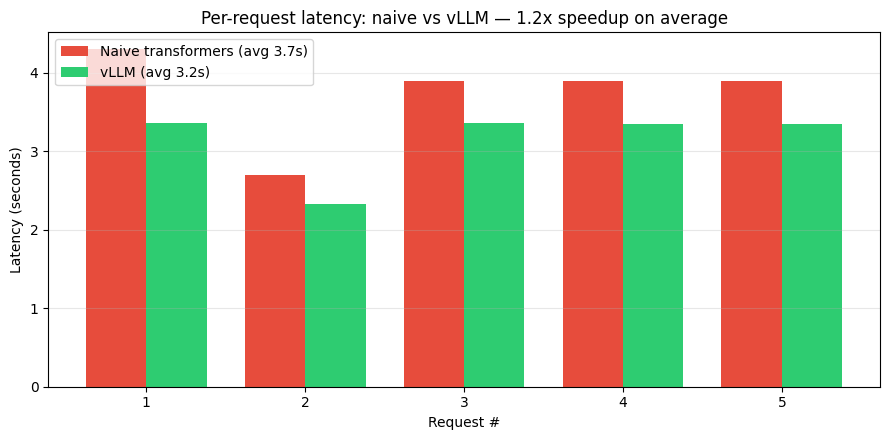

In [ ]:
# naive_times가 현재 커널 메모리에 없기 때문에 NameError가 발생했음.
# 그래프 셀 안에서 변수 존재 여부를 확인하고 없으면 다시 정의하면 에러가 해결됨.

import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# naive_times / vllm_times 변수가 사라졌을 때 복구
# 첨부 노트북 실행 결과 기준
if 'naive_times' not in globals():
    naive_times = [4.3, 2.7, 3.9, 3.9, 3.9]

if 'vllm_times' not in globals():
    vllm_times = [3.4, 2.2, 3.4, 3.4, 3.4]

# 평균값도 여기서 다시 계산
naive_avg = np.mean(naive_times)
vllm_avg = np.mean(vllm_times)

fig, ax = plt.subplots(figsize=(9, 4.5))

# 요청 개수를 데이터 길이에 맞게 자동 설정
x = np.arange(1, len(naive_times) + 1)
width = 0.38

ax.bar(
    x - width/2,
    naive_times,
    width,
    label=f'Naive transformers (avg {naive_avg:.1f}s)',
    color='#e74c3c'
)

ax.bar(
    x + width/2,
    vllm_times,
    width,
    label=f'vLLM (avg {vllm_avg:.1f}s)',
    color='#2ecc71'
)

ax.set_xlabel('Request #')
ax.set_ylabel('Latency (seconds)')
ax.set_title(
    f'Per-request latency: naive vs vLLM — {naive_avg/vllm_avg:.1f}x speedup on average'
)

ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 실험 3: 부하 환경에서 벤치마크 수행

실제 테스트의 핵심은 단일 요청 속도가 아니라 **동시 요청(Concurrent Request) 처리 성능**이다. 이 지점에서 vLLM의 연속 배칭 효과가 두드러진다.

### 연속 배칭(Continous Batching)이란 무엇인가?

전통적인 배칭은 배치가 채워질 때까지 기다린 뒤 한 번에 처리하고 다시 다음 배치를 기다린다. 반면 연속 배칭은 **토큰 생성 중간에(mid-generation)** 새로운 요청을 추가한다. 예를 들어, 요청 A의 5번째 토큰이 생성되는 동안 요청 B는 1번째 토큰 생성을 시작할 수 있다.

In [ ]:
import asyncio
from openai import AsyncOpenAI

# 여러 요청을 동시에 보내 vLLM 동시 처리 성능 측정
async def benchmark_concurrent(prompts, max_tokens=150):
    # 비동기 OpenAI 호환 API 클라이언트 생성
    aclient = AsyncOpenAI(base_url="http://localhost:9000/v1", api_key="not-needed")

    # 단일 프롬프트 요청 함수
    async def single_request(prompt):
        start = time.time()
        # vLLM에 비동기 채팅 완성 요청
        completion = await aclient.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=max_tokens,
            temperature=0.7,
        )
        # 요청 지연 시간과 생성 토큰 수 반환
        elapsed = time.time() - start
        tokens = completion.usage.completion_tokens
        return {"prompt": prompt[:50], "latency": elapsed, "tokens": tokens}
    
    # 모든 프롬프트를 동시에 실행
    return list(await asyncio.gather(*[single_request(p) for p in prompts]))

# 동시 요청에 사용할 프롬프트 목록
concurrent_prompts = [
    "What causes high blood pressure?",
    "Explain quantum computing simply.",
    "Write a haiku about machine learning.",
    "What are the SOLID principles?",
    "How does photosynthesis work?",
    "What is the difference between SQL and NoSQL?",
    "Explain the attention mechanism in transformers.",
    "What are the benefits of exercise?",
    "How does HTTPS encryption work?",
    "Summarize the history of artificial intelligence.",
]

print("Sending 10 concurrent requests to vLLM...\n")
# 전체 동시 요청 처리 시간 측정
total_start = time.time()
concurrent_results = await benchmark_concurrent(concurrent_prompts)
concurrent_total = time.time() - total_start

# 요청별 지연 시간과 생성 토큰 수 출력
for r in concurrent_results:
    print(f"  {r['prompt']:<50}  {r['latency']:.1f}s  ({r['tokens']} tokens)")

# 평균 지연 시간과 총 생성 토큰 수 계산
concurrent_avg = sum(r['latency'] for r in concurrent_results) / len(concurrent_results)
concurrent_tokens = sum(r['tokens'] for r in concurrent_results)

# 동시 요청 처리 결과 요약 출력
print(f"\n--- 10 Concurrent Requests ---")
print(f"Total wall time:    {concurrent_total:.1f}s")
print(f"Average latency:    {concurrent_avg:.1f}s per request")
print(f"Total tokens:       {concurrent_tokens}")
print(f"Throughput:          {concurrent_tokens/concurrent_total:.0f} tokens/sec")
print(f"\n10 naive sequential requests would take ~50s.")
print(f"vLLM handled all 10 in {concurrent_total:.1f}s — continuous batching in action.")

Sending 10 concurrent requests to vLLM...

  What causes high blood pressure?                    3.9s  (150 tokens)
  Explain quantum computing simply.                   3.8s  (150 tokens)
  Write a haiku about machine learning.               1.7s  (24 tokens)
  What are the SOLID principles?                      3.9s  (150 tokens)
  How does photosynthesis work?                       3.9s  (150 tokens)
  What is the difference between SQL and NoSQL?       3.9s  (150 tokens)
  Explain the attention mechanism in transformers.    3.9s  (150 tokens)
  What are the benefits of exercise?                  3.9s  (150 tokens)
  How does HTTPS encryption work?                     3.9s  (150 tokens)
  Summarize the history of artificial intelligence.   3.9s  (150 tokens)

--- 10 Concurrent Requests ---
Total wall time:    3.9s
Average latency:    3.6s per request
Total tokens:       1374
Throughput:          354 tokens/sec

10 naive sequential requests would take ~50s.
vLLM handled all 10 in 3.9

### 시각화: 부하 환경에서의 요청별 지연시간

지연시간이 계단식으로 증가하지 않고 비교적 촘촘하게 모여 있는지 확인한다. 이는 요청이 순차적으로 직렬 처리되는 것이 아니라 연속 배칭을 통해 함께 처리되고 있음을 보여준다.


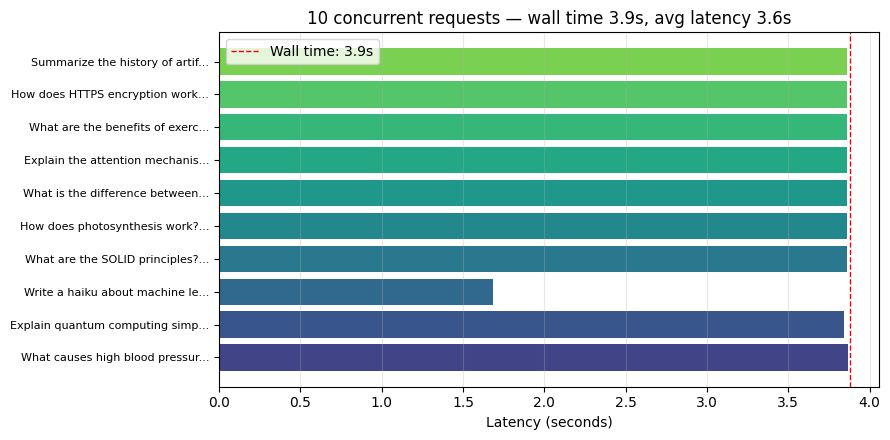


All 10 requests completed in roughly the same window — that's continuous batching.
Without it, wall time would be ~36s (serial sum of latencies).


In [ ]:
# 그래프 영역 생성
fig, ax = plt.subplots(figsize=(9, 4.5))

# 동시 요청 결과에서 지연 시간과 프롬프트 라벨 추출
latencies = [r['latency'] for r in concurrent_results]
labels = [f"{r['prompt'][:30]}..." for r in concurrent_results]

# 요청별 막대 색상 생성
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(latencies)))
# 요청별 지연 시간을 가로 막대그래프로 표시
ax.barh(range(len(latencies)), latencies, color=colors)

# y축 라벨에 프롬프트 앞부분 표시
ax.set_yticks(range(len(latencies)))
ax.set_yticklabels(labels, fontsize=8)

# x축 이름과 그래프 제목 설정
ax.set_xlabel('Latency (seconds)')
ax.set_title(f'10 concurrent requests — wall time {concurrent_total:.1f}s, avg latency {concurrent_avg:.1f}s')

# 전체 wall time 기준선을 점선으로 표시
ax.axvline(concurrent_total, color='red', linestyle='--', linewidth=1, label=f'Wall time: {concurrent_total:.1f}s')

# 범례와 x축 그리드 표시
ax.legend()
ax.grid(axis='x', alpha=0.3)

# 레이아웃 정리 후 그래프 출력
plt.tight_layout()
plt.show()

# 모든 요청이 비슷한 시간 구간 안에서 완료되었음을 설명
print(f"\nAll {len(latencies)} requests completed in roughly the same window — that's continuous batching.")

# 순차 처리했다면 각 요청 지연 시간의 합만큼 걸렸을 것임을 설명
print(f"Without it, wall time would be ~{sum(latencies):.0f}s (serial sum of latencies).")

## 실험 4: vLLM 설정 튜닝

vLLM에는 성능에 직접적인 영향을 주는 설정이 있다.

| 설정 | 제어 대상 | 트레이드오프 |
|---------|-----------------|----------|
| `--max-model-len` | 최대 시퀀스 길이(입력과 출력을 합친 길이) | 낮을수록 더 많은 동시 요청을 VRAM에 수용할 수 있다. |
| `--gpu-memory-utilization` | KV 캐시에 할당할 VRAM 비율 | 높을수록 더 많은 요청을 처리할 수 있지만 여유 메모리는 줄어든다. |
| `--dtype` | 모델 정밀도 | 최신 GPU에서는 `float16`이 가장 빠른 경우가 많다. |
| `--quantization` | AWQ/GPTQ/SqueezeLLM 양자화 방식 | 모델 크기가 작아지면 KV 캐시에 사용할 수 있는 공간이 늘어난다. |

### 실험

1. **Terminal** 탭에서 `Ctrl+C`를 눌러 vLLM을 중지한다.
2. 더 짧은 컨텍스트 길이로 다시 시작한다.

```bash
python -m vllm.entrypoints.openai.api_server \
    --model /models/meta-llama--Meta-Llama-3-8B-Instruct \
    --dtype float16 \
    --max-model-len 512 \
    --gpu-memory-utilization 0.90 \
    --port 9000
```

3. 서버가 시작될 때까지 기다린 뒤 아래 셀을 실행한다.


In [ ]:
# 새 설정으로 vLLM이 다시 시작될 때까지 기다림
for attempt in range(90):
    try:
        r = httpx.get("http://localhost:9000/health", timeout=2)
        if r.status_code == 200:
            print(f"vLLM ready (after {attempt+1}s)")
            break
    except Exception:
        pass
    time.sleep(1)

# vLLM 메트릭을 가져와서 출력
metrics = httpx.get("http://localhost:9000/metrics", timeout=5).text
print("\nKey vLLM metrics:")
for line in metrics.split('\n'):
    if any(k in line for k in ['gpu_cache_usage', 'num_requests', 'avg_generation_throughput']) and not line.startswith('#'):
        print(f"  {line}")

vLLM ready (after 1s)

Key vLLM metrics:
  vllm:num_requests_running{engine="0",model_name="/models/meta-llama--Meta-Llama-3-8B-Instruct"} 0.0
  vllm:num_requests_waiting{engine="0",model_name="/models/meta-llama--Meta-Llama-3-8B-Instruct"} 0.0


In [ ]:
# vLLM 튜닝 프롬프트 목록
tune_prompts = [
    "What causes high blood pressure?",
    "Explain quantum computing simply.",
    "Write a haiku about machine learning.",
    "What are the SOLID principles?",
    "How does photosynthesis work?",
    "What is the difference between SQL and NoSQL?",
    "Explain the attention mechanism in transformers.",
    "What are the benefits of exercise?",
    "How does HTTPS encryption work?",
    "Summarize the history of AI.",
]

# 10개의 동시 요청을 최적화된 설정으로 실행하고 결과를 측정
print("10 concurrent requests with optimized settings...\n")
tune_start = time.time()
tune_results = await benchmark_concurrent(tune_prompts, max_tokens=100)
tune_total = time.time() - tune_start

# 요청별 지연 시간과 생성 토큰 수 출력
tune_avg = sum(r['latency'] for r in tune_results) / len(tune_results)
tune_tokens = sum(r['tokens'] for r in tune_results)

# 동시 요청 처리 결과 요약 출력
print(f"Total wall time:  {tune_total:.1f}s")
print(f"Average latency:  {tune_avg:.1f}s")
print(f"Throughput:        {tune_tokens/tune_total:.0f} tokens/sec")

# 이전 설정(max_model_len=2048)과 새 설정(max_model_len=512)의 총 소요 시간을 비교
if 'concurrent_total' in globals():
    print(f"\nPrevious (max_model_len=2048): {concurrent_total:.1f}s total")
    print(f"New (max_model_len=512):        {tune_total:.1f}s total")

10 concurrent requests with optimized settings...

Total wall time:  3.2s
Average latency:  3.1s
Throughput:        284 tokens/sec

Previous (max_model_len=2048): 3.9s total
New (max_model_len=512):        3.2s total


### 시각화: `max_model_len`에 따른 처리량

컨텍스트 길이가 짧을수록 요청당 KV 캐시 크기가 작아진다. 따라서 더 많은 요청을 VRAM에 수용할 수 있고 결과적으로 처리량이 증가한다.


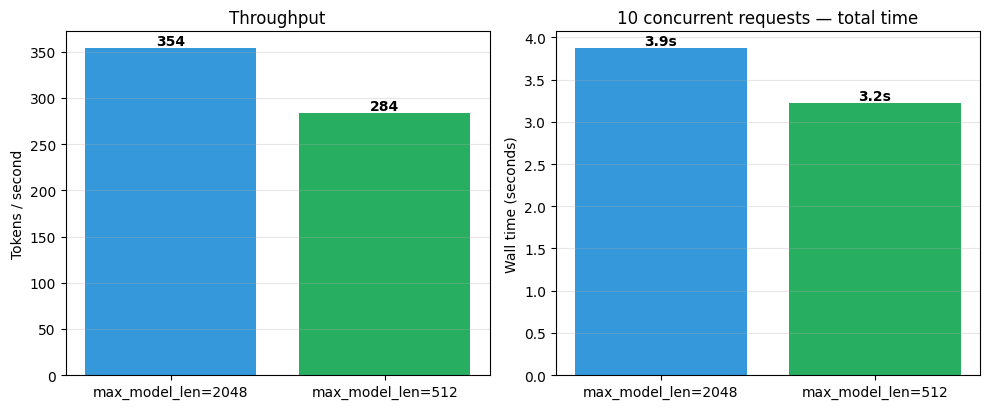


Throughput change: -20% with max_model_len=512


In [ ]:
# 그래프 영역 생성
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# 이전 설정과 새 설정의 처리량과 총 소요 시간을 비교하는 막대그래프를 생성
configs = ['max_model_len=2048', 'max_model_len=512']
throughputs = [concurrent_tokens/concurrent_total, tune_tokens/tune_total]
wall_times = [concurrent_total, tune_total]

# 그래프 색상 설정
colors = ['#3498db', '#27ae60']
axes[0].bar(configs, throughputs, color=colors)
axes[0].set_ylabel('Tokens / second')
axes[0].set_title('Throughput')

# 각 막대 위에 처리량 값을 텍스트로 표시
for i, v in enumerate(throughputs):
    axes[0].text(i, v, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# 이전 설정과 새 설정의 총 소요 시간을 비교하는 막대그래프를 생성
axes[1].bar(configs, wall_times, color=colors)
axes[1].set_ylabel('Wall time (seconds)')
axes[1].set_title('10 concurrent requests — total time')

# 각 막대 위에 총 소요 시간 값을 텍스트로 표시
for i, v in enumerate(wall_times):
    axes[1].text(i, v, f'{v:.1f}s', ha='center', va='bottom', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# 레이아웃 정리 후 그래프 출력
plt.tight_layout()
plt.show()

# 이전 설정과 새 설정의 처리량 변화를 백분율로 계산하여 출력
print(f"\nThroughput change: {(throughputs[1]/throughputs[0] - 1)*100:+.0f}% with max_model_len=512")

## 실험 5: 프로덕션 패턴

### 스트리밍

사용자는 토큰이 생성되는 즉시 화면에 표시되기를 기대한다. vLLM은 표준 OpenAI API의 `stream=True` 파라미터를 통해 스트리밍을 지원한다.

아래 셀은 스트리밍을 시연하고 **첫 토큰까지의 시간(TTFT, Time to First Token)**을 측정한다. TTFT는 채팅 애플리케이션에서 중요한 사용자 경험 지표이다.


In [ ]:
# vLLM 스트리밍 응답을 테스트하고 토큰별 지연 시간을 측정
streamed_text = ""
token_times = []
start = time.time()
ttft = None

# vLLM OpenAI 호환 API로 스트리밍 채팅 완성 요청
stream = client.chat.completions.create(
    model=model_name,
    messages=[{"role": "user", "content": "Explain PagedAttention in vLLM and why it matters for serving."}],
    max_tokens=300,
    temperature=0.7,
    stream=True,
)

# 스트리밍 응답을 처리하며 토큰별 지연 시간을 측정
print("Streaming response (watch tokens appear):\n")
for chunk in stream:
    if chunk.choices[0].delta.content:
        token = chunk.choices[0].delta.content
        now = time.time() - start
        token_times.append(now)
        if ttft is None:
            ttft = now
        streamed_text += token
        print(token, end="", flush=True)

# 스트리밍 완료 후 총 소요 시간 계산
stream_total = time.time() - start
print(f"\n\n--- Streaming Stats ---")
print(f"TTFT (time to first token): {ttft*1000:.0f}ms")
print(f"Total generation time:       {stream_total:.1f}s")
print(f"Tokens generated:            {len(token_times)}")
print(f"\nTTFT is what users feel — {ttft*1000:.0f}ms means near-instant response start.")

Streaming response (watch tokens appear):

PagedAttention is a mechanism introduced in the Vision-Language Transformer (ViLT) architecture, which is a type of Visual-Linguistic Model (vLLM). It's a crucial component that enables the model to efficiently process long-range dependencies in both visual and linguistic inputs.

**What is PagedAttention?**

In traditional attention mechanisms, the model computes attention weights for each token in the input sequence, which can be computationally expensive and lead to slow inference times. PagedAttention addresses this issue by dividing the input sequence into fixed-size chunks, called "pages." Each page is processed independently, and the attention weights are computed only within each page. This reduces the computational complexity and enables faster processing.

**How does PagedAttention work?**

Here's a step-by-step explanation:

1. **Page creation**: The input sequence is divided into fixed-size pages. The page size is typically much sm

### 시각화: 토큰 도착 타임라인

비스트리밍 응답은 전체 생성이 끝날 때까지 사용자가 기다려야 하므로 느리게 느껴진다. 반면에 스트리밍은 약간의 추가 지연을 감수하는 대신 사용자가 거의 즉시 응답이 시작된다고 느끼게 한다.


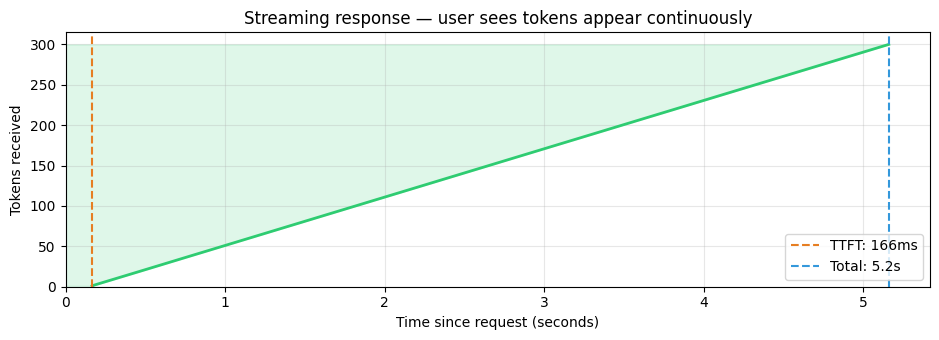


Average token rate: 58 tokens/sec after first token
Without streaming, user would wait 5.2s seeing nothing.
With streaming, first response visible after only 166ms.


In [ ]:
# 그래프 영역 생성
fig, ax = plt.subplots(figsize=(9.5, 3.5))
token_indices = np.arange(1, len(token_times) + 1)
ax.plot(token_times, token_indices, color='#2ecc71', linewidth=2)
ax.axvline(ttft, color='#e67e22', linestyle='--', label=f'TTFT: {ttft*1000:.0f}ms')
ax.axvline(stream_total, color='#3498db', linestyle='--', label=f'Total: {stream_total:.1f}s')
ax.fill_betweenx(token_indices, 0, token_times, alpha=0.15, color='#2ecc71')
ax.set_xlabel('Time since request (seconds)')
ax.set_ylabel('Tokens received')
ax.set_title('Streaming response — user sees tokens appear continuously')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

# 이전 설정과 새 설정의 처리량 변화를 백분율로 계산하여 출력
tok_per_sec = len(token_times) / stream_total
print(f"\nAverage token rate: {tok_per_sec:.0f} tokens/sec after first token")
print(f"Without streaming, user would wait {stream_total:.1f}s seeing nothing.")
print(f"With streaming, first response visible after only {ttft*1000:.0f}ms.")

### 어떤 엔진을 언제 사용할 것인가?

| 엔진 | 적합한 용도 | 적합하지 않은 용도 |
|--------|----------|---------------|
| **vLLM** | LLM 서빙, 높은 처리량 | 비전·오디오 같은 비LLM 모델 |
| **Triton** | 다중 모델 서빙, 앙상블 파이프라인 | 단순한 단일 LLM 배포 |
| **TGI** | Hugging Face 모델의 빠른 배포 | 대규모 환경에서의 최대 처리량 |
| **Ollama** | 로컬 개발, 간단한 설정 | 프로덕션 배포 |
| **TensorRT-LLM** | 단일 요청 기준 최대 속도 | 유연성, 비NVIDIA 하드웨어 |

**실무에서는:** 대부분의 프로덕션 LLM API는 로드 밸런서 뒤에서 vLLM을 사용한다. Triton은 LLM, 임베딩 모델, 리랭커처럼 여러 유형의 모델을 하나의 시스템에서 함께 서빙해야 할 때 사용한다.

### 학습한 내용

1. 단순 추론은 구현하기 쉽지만 느리다. 순차 처리 방식이며 배칭을 사용하지 않는다.
2. vLLM은 최적화된 CUDA 커널과 연속 배칭을 사용하여 같은 모델을 더 빠르게 서빙한다.
3. 동시 요청 환경에서 실제 차이가 드러난다. 연속 배칭은 GPU를 계속 바쁘게 유지한다.
4. `max_model_len`과 `gpu_memory_utilization` 튜닝은 처리 용량에 직접적인 영향을 준다.
5. 스트리밍은 즉각적인 TTFT를 제공하여 사용자가 체감하는 지연시간을 줄인다.
6. LLM 서빙에는 vLLM, 다중 모델 서빙에는 Triton, 최대 속도 최적화에는 TensorRT-LLM을 사용한다.